Imports and setup
This cell brings in all the libraries and project utilities the notebook relies on. It imports SymPy tools for symbolic parsing of equations and conversion to a matrix form, NumPy for numerical arrays and linear algebra, `tabulate` for formatted tables, and Matplotlib for plotting. It also imports every direct and iterative solver implemented in the `method/` package and several matrix helpers from `matrix/funcs.py` (triangular conversion, determinant, inverse, spectral radius, diagonal dominance checks, etc.). Finally, it defines `e = 1e-2` as a tolerance value; note that the iterative methods themselves use their own default tolerance inside `norm_handler` unless overridden there.

In [1]:
from sympy import symbols, sympify, SympifyError, linear_eq_to_matrix
import numpy as np
import tabulate as tb
import matplotlib.pyplot as plt

from method.choleskydecomposition import cholesky_decomposition
from method.gaussianelimination import Gaussian_Elimination_method
from method.cramer import cramer_method
from method.jacobi import jacobi_method
from method.gaussseidel import gauss_seidel_method
from method.sor import sor_method
from method.doolittle import doolittle
from method.croutdecomposition import crout_decomposition

from matrix.funcs import Lower_Triangular_Matrix_Convertor, check_diagonal_dominance_row, check_diagonal_dominance_col, Spectral_radius, cal_B, calculate_determinant , Upper_Triangular_Matrix_Convertor, inverse_matrix,Lower_Triangular_Matrix_Convertor, inverse_matrix

e = 10**-2

Read number of equations
This loop prompts the user to enter the number of equations, validates that the input is an integer, and repeats on invalid input. The final value is printed for confirmation, and it drives how many equations will be collected later.

In [2]:
while True:
    try:

        n = int(input("Enter number of equations you want to insert: "))

        break
    
    except:
        print("Invalid input. Please enter again")

print(f"The number of equations is {n}")

The number of equations is 3


Read number of variables
This loop asks for the number of variables and enforces that it matches the number of equations. If the counts differ, it prompts again because the linear system is expected to be square. The validated number is printed.

In [3]:
while True:
    try:

        m = int(input("Enter number of variables of equations: "))
        
        if m != n:
            print("Number of variables must be equal to number of equations. Please enter again")
            continue

        break
    
    except:
        print("Invalid input. Please enter again")

print(f"The number of variables is {m}")

The number of variables is 3


Choose variable symbol
This input asks for the base symbol used to name variables (for example, `x` so variables become `x1, x2, ...`). The symbol is lowercased and printed, and it is used to build the SymPy symbols in the next cell.

In [4]:
while True:
    try:

        base_symbol = input("Enter your equation's symbol (e.g. x): ").lower()

        break
    
    except:
        print("Invalid input. Please enter again")

print(f"The equation's symbol is {base_symbol}")

The equation's symbol is x


Read SOR relaxation factor
This loop reads the relaxation parameter `w` for the SOR method, validates that it is numeric, and prints the value. `w` controls over/under-relaxation in the SOR iterations.

In [5]:
while True:
    try:

        w = float(input("Enter w for SOR Method: "))

        break
    
    except:
        print("Invalid input. Please enter again")

print(f"The w for SOR Method is {w}")

The w for SOR Method is 1.2


Read iteration limit
This loop reads the maximum number of iterations `k` for iterative solvers (Jacobi, Gauss-Seidel, SOR). It validates integer input and prints the chosen limit.

In [6]:
while True:
    try:

        k = int(input("Enter Maximum of iterations: "))

        break
    
    except:
        print("Invalid input. Please enter again")

print(f"Maximum of iterations {k}")

Maximum of iterations 10


Construct symbolic variables
This cell creates a tuple of SymPy symbols named according to the chosen base symbol and the number of variables, e.g., `x1, x2, ..., xm`. These symbols are used to parse input equations and build the coefficient matrix.

In [7]:
variables = symbols(f"{base_symbol}1:{m+1}")

Collect and parse equations
This cell loops `n` times to read each equation as a string, stores a printable version, and splits each input into left/right sides around `=`. It then converts each side to a SymPy expression and moves all terms to the left (`left - right`) so the equation becomes `expr = 0`. Any malformed input is rejected and re-prompted. Finally, it prints back all the equations that were accepted.

In [8]:
equations = []
print_lines = []

for i in range(1, n+1):
    while True:
        try:

            equation = input(f"Enter equation {i}: ")

            print_lines.append(f"Equation {i}: {equation}")

            left, right = equation.split("=")

            eq = sympify(left) - sympify(right)

            equations.append(eq)

            break
        
        except (ValueError, SympifyError):
            print("Invalid equation format. Try again.")

print("The equations you entered are:")
for eq in print_lines:
    print(eq)

The equations you entered are:
Equation 1: x1 + 5*x2 + 3*x3 = 3
Equation 2: 4*x1 - 2*x2 - 5*x3 = 7
Equation 3: 2*x1 + 3*x2 - x3 = 6


Build numeric A and b
Here the symbolic system is converted into matrix form `A * x = b` via `linear_eq_to_matrix`. The resulting SymPy matrices are cast to NumPy arrays of type `float`, producing the numeric coefficient matrix `A` and right-hand side vector `b`.

In [9]:
A_sym, b_sym = linear_eq_to_matrix(equations, variables)

A = np.array(A_sym, dtype=float)
b = np.array(b_sym, dtype=float)

Initial guess for iterative methods
This computes an initial guess vector `x0` by dividing each right-hand side entry by the corresponding diagonal element of `A` (i.e., `b_i / A_ii`). The list is then converted into a column vector of shape `(n, 1)` to match the solvers’ expected input.

In [10]:
x0 = []

for i in range(A.shape[0]):
    
    x0.append(b[i , 0] / A[i , i])

x0 = np.array(x0).reshape(A.shape[0], 1)

Run all solvers
This cell executes every available method on the same system. It computes direct solutions (Cramer’s Rule, Gaussian Elimination, Doolittle LU, Cholesky, Crout) and iterative solutions (Jacobi, Gauss-Seidel, SOR) for three different norms (`one`, `two`, `infinity`). The returned results are stored for later printing and comparison.

In [14]:
cramer_method_answers = cramer_method(A, b)

Gaussian_Elimination_method_answers = Gaussian_Elimination_method(A, b)

doolittle_x , doolittle_y  , doolittle_L , doolittle_U = doolittle(A, b)

cholesky_result = cholesky_decomposition(A , b)

crout_result = crout_decomposition(A , b)

jacobi_method_norm_one = jacobi_method("one", x0, k, A, b)

jacobi_method_norm_two = jacobi_method("two", x0, k, A, b)

jacobi_method_norm_infinity = jacobi_method("infinity", x0, k, A, b)

gauss_seidel_method_norm_one = gauss_seidel_method("one", x0, k, A, b)

gauss_seidel_method_norm_two = gauss_seidel_method("two", x0, k, A, b)

gauss_seidel_method_norm_infinity = gauss_seidel_method("infinity", x0, k, A, b)


sor_method_answers_norm_one = sor_method("one", w, x0, k, A, b)

sor_method_answers_norm_two = sor_method("two", w, x0, k, A, b)

sor_method_answers_norm_infinity = sor_method("infinity", w, x0, k, A, b)

Display Cramer’s Rule solution
This cell formats the solution from Cramer’s Rule into a single-column table. Each variable is printed with six decimal places using `tabulate` for a clean console view.

In [15]:
t = [["Cramer's Method Solution"]]

for i in range(len(cramer_method_answers)):
    
    t.append([f"{variables[i]} = {cramer_method_answers[i]:.6f}"])

print(tb.tabulate(t, headers="firstrow", tablefmt="rounded_grid"))

╭────────────────────────────╮
│ Cramer's Method Solution   │
├────────────────────────────┤
│ x1 = 1.000000              │
├────────────────────────────┤
│ x2 = 1.000000              │
├────────────────────────────┤
│ x3 = -1.000000             │
╰────────────────────────────╯


Display Gaussian Elimination solution
This formats the Gaussian Elimination results in a table, labeling each component as `x1`, `x2`, etc., and prints them with six decimal places.

In [16]:
t = [["Gaussian Elimination Method"]]

for i in range(len(Gaussian_Elimination_method_answers)):
    
    t.append([f" x{i+1} = {Gaussian_Elimination_method_answers[i]:.6f}"])

print(tb.tabulate(t, headers="firstrow", tablefmt="rounded_grid"))

╭───────────────────────────────╮
│ Gaussian Elimination Method   │
├───────────────────────────────┤
│ x1 = 1.000000                 │
├───────────────────────────────┤
│ x2 = 1.000000                 │
├───────────────────────────────┤
│ x3 = -1.000000                │
╰───────────────────────────────╯


Display Doolittle LU results
This cell prints two tables: the solution vector `x` and the intermediate vector `y` from the Doolittle LU decomposition. Both are shown component-wise with six decimal places.

In [17]:
t = [["X Matrix of Doolittle's Method"]]

for i in range(len(doolittle_x)):

    t.append([f" x{i+1} = {doolittle_x[i][0]:.6f}"])

print(tb.tabulate(t, headers="firstrow", tablefmt="rounded_grid"))


t = [["Y Matrix of Doolittle's Method"]]

for i in range(len(doolittle_x)):
    
    t.append([f" y{i+1} = {doolittle_y[i][0]:.6f}"])

print(tb.tabulate(t, headers="firstrow", tablefmt="rounded_grid"))

╭──────────────────────────────────╮
│ X Matrix of Doolittle's Method   │
├──────────────────────────────────┤
│ x1 = 1.000000                    │
├──────────────────────────────────┤
│ x2 = 1.000000                    │
├──────────────────────────────────┤
│ x3 = -1.000000                   │
╰──────────────────────────────────╯
╭──────────────────────────────────╮
│ Y Matrix of Doolittle's Method   │
├──────────────────────────────────┤
│ y1 = 3.000000                    │
├──────────────────────────────────┤
│ y2 = -5.000000                   │
├──────────────────────────────────┤
│ y3 = 1.590909                    │
╰──────────────────────────────────╯


Display Cholesky results (if applicable)
Cholesky only works for positive definite matrices. This cell checks the return value and either prints an explanatory message or unpacks `x`, `y`, and the triangular factors `L` and `Lᵀ`. It then prints tables for `x` and `y` similar to the Doolittle output.

In [18]:
cholesky_final = True

if cholesky_result == "Matrix is not positive definite.":

    print("Cholesky's Method cannot be applied because the matrix is not positive definite.")

    cholesky_final = False

else:
    
    cholesky_x , cholesky_y , cholesky_L , cholesky_Lt = cholesky_result

    t = [["X Matrix of Cholesky's Method"]]

    for i in range(len(cholesky_x)):

        t.append([f" x{i+1} = {cholesky_x[i][0]:.6f}"])

    print(tb.tabulate(t, headers="firstrow", tablefmt="rounded_grid"))


    t = [["Y Matrix of Cholesky's Method"]]

    for i in range(len(cholesky_y)):
        
        t.append([f" y{i+1} = {cholesky_y[i][0]:.6f}"])

    print(tb.tabulate(t, headers="firstrow", tablefmt="rounded_grid"))

Cholesky's Method cannot be applied because the matrix is not positive definite.


Display Crout results (if applicable)
Crout decomposition fails if a zero pivot is encountered. This cell checks for that condition, prints a warning if needed, or prints the `x` and `y` vectors in table form when the decomposition succeeds.

In [19]:
crout_final = True

if crout_result == "Zero pivot encountered in Crout decomposition.":

    print("Crout's Method cannot be applied because a zero pivot was encountered.")

    crout_final = False

else:
    
    crout_x , crout_y , crout_L , crout_U = crout_result

    t = [["X Matrix of Crout's Method"]]

    for i in range(len(crout_x)):

        t.append([f" x{i+1} = {crout_x[i]:.6f}"])

    print(tb.tabulate(t, headers="firstrow", tablefmt="rounded_grid"))


    t = [["Y Matrix of Crout's Method"]]

    for i in range(len(crout_y)):
        
        t.append([f" y{i+1} = {crout_y[i]:.6f}"])

    print(tb.tabulate(t, headers="firstrow", tablefmt="rounded_grid"))

╭──────────────────────────────╮
│ X Matrix of Crout's Method   │
├──────────────────────────────┤
│ x1 = 1.000000                │
├──────────────────────────────┤
│ x2 = 1.000000                │
├──────────────────────────────┤
│ x3 = -1.000000               │
╰──────────────────────────────╯
╭──────────────────────────────╮
│ Y Matrix of Crout's Method   │
├──────────────────────────────┤
│ y1 = 3.000000                │
├──────────────────────────────┤
│ y2 = 0.227273                │
├──────────────────────────────┤
│ y3 = -1.000000               │
╰──────────────────────────────╯


Jacobi iterations (norm one)
This prints a table of all stored Jacobi iterates when the stopping test uses the 1-norm. Each row is labeled `Stage i` to show the iteration progression.

In [20]:
print("Jacobi Method (Norm One) Iterations:")

levels = [f"Stage {i}" for i in range(len(jacobi_method_norm_one))]

print(tb.tabulate(jacobi_method_norm_one, headers=variables, tablefmt="rounded_grid", showindex=levels, numalign="center"))

Jacobi Method (Norm One) Iterations:
╭──────────┬──────────────┬──────────────┬─────────────╮
│          │      x1      │      x2      │     x3      │
├──────────┼──────────────┼──────────────┼─────────────┤
│ Stage 0  │      3       │     -3.5     │     -6      │
├──────────┼──────────────┼──────────────┼─────────────┤
│ Stage 1  │     38.5     │     17.5     │    -10.5    │
├──────────┼──────────────┼──────────────┼─────────────┤
│ Stage 2  │     -53      │    99.75     │    123.5    │
├──────────┼──────────────┼──────────────┼─────────────┤
│ Stage 3  │   -866.25    │   -418.25    │   187.25    │
├──────────┼──────────────┼──────────────┼─────────────┤
│ Stage 4  │    1532.5    │   -2204.12   │  -2993.25   │
├──────────┼──────────────┼──────────────┼─────────────┤
│ Stage 5  │   20003.4    │   10544.6    │  -3553.38   │
├──────────┼──────────────┼──────────────┼─────────────┤
│ Stage 6  │    -42060    │   48886.7    │   71634.6   │
├──────────┼──────────────┼──────────────┼─────────

Jacobi iterations (norm two)
This prints the same Jacobi iteration table but with the stopping condition based on the 2-norm.

In [21]:
print("Jacobi Method (Norm Two) Iterations:")

levels = [f"Stage {i}" for i in range(len(jacobi_method_norm_two))]

print(tb.tabulate(jacobi_method_norm_two, headers=variables, tablefmt="rounded_grid", showindex=levels, numalign="center"))

Jacobi Method (Norm Two) Iterations:
╭──────────┬──────────────┬──────────────┬─────────────╮
│          │      x1      │      x2      │     x3      │
├──────────┼──────────────┼──────────────┼─────────────┤
│ Stage 0  │      3       │     -3.5     │     -6      │
├──────────┼──────────────┼──────────────┼─────────────┤
│ Stage 1  │     38.5     │     17.5     │    -10.5    │
├──────────┼──────────────┼──────────────┼─────────────┤
│ Stage 2  │     -53      │    99.75     │    123.5    │
├──────────┼──────────────┼──────────────┼─────────────┤
│ Stage 3  │   -866.25    │   -418.25    │   187.25    │
├──────────┼──────────────┼──────────────┼─────────────┤
│ Stage 4  │    1532.5    │   -2204.12   │  -2993.25   │
├──────────┼──────────────┼──────────────┼─────────────┤
│ Stage 5  │   20003.4    │   10544.6    │  -3553.38   │
├──────────┼──────────────┼──────────────┼─────────────┤
│ Stage 6  │    -42060    │   48886.7    │   71634.6   │
├──────────┼──────────────┼──────────────┼─────────

Jacobi iterations (norm infinity)
This prints the Jacobi iteration table using the infinity norm stopping condition.

In [22]:
print("Jacobi Method (Norm Infinity) Iterations:")

levels = [f"Stage {i}" for i in range(len(jacobi_method_norm_infinity))]

print(tb.tabulate(jacobi_method_norm_infinity, headers=variables, tablefmt="rounded_grid", showindex=levels, numalign="center"))

Jacobi Method (Norm Infinity) Iterations:
╭─────────┬─────────┬──────────┬──────────╮
│         │   x1    │    x2    │    x3    │
├─────────┼─────────┼──────────┼──────────┤
│ Stage 0 │    3    │   -3.5   │    -6    │
├─────────┼─────────┼──────────┼──────────┤
│ Stage 1 │  38.5   │   17.5   │  -10.5   │
├─────────┼─────────┼──────────┼──────────┤
│ Stage 2 │   -53   │  99.75   │  123.5   │
├─────────┼─────────┼──────────┼──────────┤
│ Stage 3 │ -866.25 │ -418.25  │  187.25  │
├─────────┼─────────┼──────────┼──────────┤
│ Stage 4 │ 1532.5  │ -2204.12 │ -2993.25 │
├─────────┼─────────┼──────────┼──────────┤
│ Stage 5 │ 20003.4 │ 10544.6  │ -3553.38 │
├─────────┼─────────┼──────────┼──────────┤
│ Stage 6 │ -42060  │ 48886.7  │ 71634.6  │
├─────────┼─────────┼──────────┼──────────┤
│ Stage 7 │ -459334 │ -263210  │ 62534.1  │
╰─────────┴─────────┴──────────┴──────────╯


Gauss-Seidel iterations (norm one)
This prints all Gauss-Seidel iterates using the 1-norm stopping criterion, again labeling each row with an iteration stage.

In [23]:
print("Gauss Seidel (Norm One) Iterations:")

levels = [f"Stage {i}" for i in range(len(gauss_seidel_method_norm_one))]

print(tb.tabulate(gauss_seidel_method_norm_one, headers=variables, tablefmt="rounded_grid", showindex=levels, numalign="center"))

Gauss Seidel (Norm One) Iterations:
╭──────────┬──────────────┬──────────────┬──────────────╮
│          │      x1      │      x2      │      x3      │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 0  │      3       │     -3.5     │      -6      │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 1  │     38.5     │     88.5     │    336.5     │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 2  │    -1449     │   -3742.75   │   -14132.2   │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 3  │   61113.5    │    157554    │    594883    │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 4  │ -2.57242e+06 │ -6.63205e+06 │ -2.5041e+07  │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 5  │ 1.08283e+08  │ 2.79169e+08  │ 1.05407e+09  │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 6  │ -4.55806e+09 │ -1.17513e+10 │  -4.437e+10  │
├──────────┼──────────────┼─────────

Gauss-Seidel iterations (norm two)
This prints Gauss-Seidel iterates when the stopping test uses the 2-norm.

In [24]:
print("Gauss Seidel (Norm Two) Iterations:")

levels = [f"Stage {i}" for i in range(len(gauss_seidel_method_norm_two))]

print(tb.tabulate(gauss_seidel_method_norm_two, headers=variables, tablefmt="rounded_grid", showindex=levels, numalign="center"))

Gauss Seidel (Norm Two) Iterations:
╭──────────┬──────────────┬──────────────┬──────────────╮
│          │      x1      │      x2      │      x3      │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 0  │      3       │     -3.5     │      -6      │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 1  │     38.5     │     88.5     │    336.5     │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 2  │    -1449     │   -3742.75   │   -14132.2   │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 3  │   61113.5    │    157554    │    594883    │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 4  │ -2.57242e+06 │ -6.63205e+06 │ -2.5041e+07  │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 5  │ 1.08283e+08  │ 2.79169e+08  │ 1.05407e+09  │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 6  │ -4.55806e+09 │ -1.17513e+10 │  -4.437e+10  │
├──────────┼──────────────┼─────────

Gauss-Seidel iterations (norm infinity)
This prints Gauss-Seidel iterates when the stopping test uses the infinity norm.

In [25]:
print("Gauss Seidel (Norm Infinity) Iterations:")

levels = [f"Stage {i}" for i in range(len(gauss_seidel_method_norm_infinity))]

print(tb.tabulate(gauss_seidel_method_norm_infinity, headers=variables, tablefmt="rounded_grid", showindex=levels, numalign="center"))

Gauss Seidel (Norm Infinity) Iterations:
╭─────────┬───────┬──────────┬──────────╮
│         │  x1   │    x2    │    x3    │
├─────────┼───────┼──────────┼──────────┤
│ Stage 0 │   3   │   -3.5   │    -6    │
├─────────┼───────┼──────────┼──────────┤
│ Stage 1 │ 38.5  │   88.5   │  336.5   │
├─────────┼───────┼──────────┼──────────┤
│ Stage 2 │ -1449 │ -3742.75 │ -14132.2 │
╰─────────┴───────┴──────────┴──────────╯


SOR iterations (norm one)
This prints all stored SOR iterates when the stopping condition is based on the 1-norm.

In [26]:
print("SOR (Norm One) Iterations:")

levels = [f"Stage {i}" for i in range(len(sor_method_answers_norm_one))]

print(tb.tabulate(sor_method_answers_norm_one, headers=variables, tablefmt="rounded_grid", showindex=levels, numalign="center"))

SOR (Norm One) Iterations:
╭──────────┬──────────────┬──────────────┬──────────────╮
│          │      x1      │      x2      │      x3      │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 0  │      3       │     -3.5     │      -6      │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 1  │     45.6     │    123.94    │   549.624    │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 2  │   -2727.81   │   -8224.6    │   -36272.4   │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 3  │    180477    │    543604    │ 2.39737e+06  │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 4  │ -1.19282e+07 │ -3.59286e+07 │ -1.5845e+08  │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 5  │ 7.88378e+08  │ 2.37464e+09  │ 1.04725e+10  │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 6  │ -5.21066e+10 │ -1.56948e+11 │ -6.92164e+11 │
├──────────┼──────────────┼──────────────┼───

SOR iterations (norm two)
This prints the SOR iteration table using the 2-norm for the stopping test.

In [27]:
print("SOR (Norm Two) Iterations:")

levels = [f"Stage {i}" for i in range(len(sor_method_answers_norm_two))]

print(tb.tabulate(sor_method_answers_norm_two, headers=variables, tablefmt="rounded_grid", showindex=levels, numalign="center"))

SOR (Norm Two) Iterations:
╭──────────┬──────────────┬──────────────┬──────────────╮
│          │      x1      │      x2      │      x3      │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 0  │      3       │     -3.5     │      -6      │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 1  │     45.6     │    123.94    │   549.624    │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 2  │   -2727.81   │   -8224.6    │   -36272.4   │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 3  │    180477    │    543604    │ 2.39737e+06  │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 4  │ -1.19282e+07 │ -3.59286e+07 │ -1.5845e+08  │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 5  │ 7.88378e+08  │ 2.37464e+09  │ 1.04725e+10  │
├──────────┼──────────────┼──────────────┼──────────────┤
│ Stage 6  │ -5.21066e+10 │ -1.56948e+11 │ -6.92164e+11 │
├──────────┼──────────────┼──────────────┼───

SOR iterations (norm infinity)
This prints the SOR iteration table using the infinity norm for the stopping test.

In [28]:
print("SOR (Norm Infinity) Iterations:")

levels = [f"Stage {i}" for i in range(len(sor_method_answers_norm_infinity))]

print(tb.tabulate(sor_method_answers_norm_infinity, headers=variables, tablefmt="rounded_grid", showindex=levels, numalign="center"))

SOR (Norm Infinity) Iterations:
╭─────────┬──────────┬─────────┬──────────╮
│         │    x1    │   x2    │    x3    │
├─────────┼──────────┼─────────┼──────────┤
│ Stage 0 │    3     │  -3.5   │    -6    │
├─────────┼──────────┼─────────┼──────────┤
│ Stage 1 │   45.6   │ 123.94  │ 549.624  │
├─────────┼──────────┼─────────┼──────────┤
│ Stage 2 │ -2727.81 │ -8224.6 │ -36272.4 │
╰─────────┴──────────┴─────────┴──────────╯


Analysis Part 1: general matrix info
This cell builds and prints a summary table describing the input system. It reports shapes, the matrix and vector contents, the rank and determinant, whether the matrix is singular or square, symmetry, and diagonal dominance checks (row and column). This provides quick diagnostics about the system before interpreting solver results.

In [29]:
print("Analyze part 1. General Info.")

details = [
    ["Shape of A", str(A.shape)],
    ["Matrix A", str(A)],
    ["Rank of A", str(np.linalg.matrix_rank(A))],
    ["Determinant of A", str(calculate_determinant(A))],
    ["Is A singular?", "Yes" if np.isclose(calculate_determinant(A), 0) else "No"],
    ["Is A square?", "Yes" if A.shape[0] == A.shape[1] else "No"],
    ["Is A symmetric?", "Yes" if np.allclose(A, A.T) else "No"],
    ["Is A diagonally dominant (row)?", "Yes" if check_diagonal_dominance_row(A) else "No"],
    ["Is A diagonally dominant (col)?", "Yes" if check_diagonal_dominance_col(A) else "No"],
    ["Shape of b", str(b.shape)],
    ["Vector b", str(b.ravel())]
]

print(tb.tabulate(details, headers=["General Info", "Value"], tablefmt="rounded_grid", stralign="center"))

Analyze part 1. General Info.
╭─────────────────────────────────┬─────────────────╮
│          General Info           │      Value      │
├─────────────────────────────────┼─────────────────┤
│           Shape of A            │     (3, 3)      │
├─────────────────────────────────┼─────────────────┤
│            Matrix A             │ [[ 1.  5.  3.]  │
│                                 │  [ 4. -2. -5.]  │
│                                 │  [ 2.  3. -1.]] │
├─────────────────────────────────┼─────────────────┤
│            Rank of A            │        3        │
├─────────────────────────────────┼─────────────────┤
│        Determinant of A         │      35.0       │
├─────────────────────────────────┼─────────────────┤
│         Is A singular?          │       No        │
├─────────────────────────────────┼─────────────────┤
│          Is A square?           │       Yes       │
├─────────────────────────────────┼─────────────────┤
│         Is A symmetric?         │       No        

Analysis Part 1: inverse and triangular forms
This computes the inverse of `A` and converts `A` into upper and lower triangular forms using custom helpers. The results are placed into a table to show additional structural information about the coefficient matrix.

In [30]:
A_Upper_Triangular = Upper_Triangular_Matrix_Convertor(A)
A_Lower_Triangular = Lower_Triangular_Matrix_Convertor(A)
A_inv = inverse_matrix(A)

details = [
    ["Inverse of Matrix A", str(A_inv)],
    ["Upper Triangular Matrix A", str(A_Upper_Triangular)],
    ["Lower Triangular Matrix A", str(A_Lower_Triangular)]
]

print(tb.tabulate(details, headers=["Other Info about Matrix A", "Value"], tablefmt="rounded_grid", stralign="center"))

╭─────────────────────────────┬────────────────────────────────────────────╮
│  Other Info about Matrix A  │                   Value                    │
├─────────────────────────────┼────────────────────────────────────────────┤
│     Inverse of Matrix A     │   [[ 0.48571429  0.4        -0.54285714]   │
│                             │    [-0.17142857 -0.2         0.48571429]   │
│                             │   [ 0.45714286  0.2        -0.62857143]]   │
├─────────────────────────────┼────────────────────────────────────────────┤
│  Upper Triangular Matrix A  │ [[  1.           5.           3.        ]  │
│                             │  [  0.         -22.         -17.        ]  │
│                             │  [  0.           0.          -1.59090909]] │
├─────────────────────────────┼────────────────────────────────────────────┤
│  Lower Triangular Matrix A  │ [[  2.05882353   0.           0.        ]  │
│                             │  [ -6.         -17.           0.        ]  │

Analysis Part 2: direct method details
This cell checks the determinant to decide if Cramer’s Rule is applicable and reports the result. It then prints the `L` and `U` matrices from Doolittle’s method. If Cholesky or Crout succeeded earlier, it also prints their triangular factors so you can compare decompositions across methods.

In [31]:
print("Analyze Part 2. Direct mothods (Cramer / Gaussian Elimination / Doolittle / Cholesky / Crout methods).")

det = calculate_determinant(A)

if np.isclose(det, 0):

    cramer_details = [["Singularity", "Matrix A is singular, so Cramer's method cannot be applied."]]

else:
    
    cramer_details = [["Singularity", "Matrix A is not singular, so Cramer's method can be applied."]]

doolittle_details = [
    ["L Matrix:", str(doolittle_L)],
    ["U Matrix:", str(doolittle_U)],
]

print(tb.tabulate(cramer_details, headers=["Cramer's Method", "Details"], tablefmt="rounded_grid", stralign="center"))
print(tb.tabulate(doolittle_details, headers=["Doolittle's Method", "Deatails"], tablefmt="rounded_grid", stralign="center"))

if cholesky_final:
    
    cholesky_details = [
        ["L Matrix:", str(cholesky_L)],
        ["U Matrix:", str(cholesky_Lt)],
    ]

    print(tb.tabulate(cholesky_details, headers=["Cholesky's Method", "Deatails"], tablefmt="rounded_grid", stralign="center"))

if crout_final:

    crout_details = [
        ["L Matrix:", str(crout_L)],
        ["U Matrix:", str(crout_U)],
    ]

    print(tb.tabulate(crout_details, headers=["Crout's Method", "Deatails"], tablefmt="rounded_grid", stralign="center"))

Analyze Part 2. Direct mothods (Cramer / Gaussian Elimination / Doolittle / Cholesky / Crout methods).
╭───────────────────┬──────────────────────────────────────────────────────────────╮
│  Cramer's Method  │                           Details                            │
├───────────────────┼──────────────────────────────────────────────────────────────┤
│    Singularity    │ Matrix A is not singular, so Cramer's method can be applied. │
╰───────────────────┴──────────────────────────────────────────────────────────────╯
╭──────────────────────┬────────────────────────────────────────────╮
│  Doolittle's Method  │                  Deatails                  │
├──────────────────────┼────────────────────────────────────────────┤
│      L Matrix:       │    [[1.         0.         0.        ]     │
│                      │     [4.         1.         0.        ]     │
│                      │     [2.         0.31818182 1.        ]]    │
├──────────────────────┼────────────────────────────

Compare direct methods’ solutions
This compares the solution vectors returned by Doolittle, and (if available) Cholesky and Crout. It computes pairwise equality via `np.allclose` and also reports the L-infinity norm of the differences for each pair.

In [32]:
print("Comparison of Doolittle / Cholesky / Crout methods with eachother (If Exists)")
dx = np.array(doolittle_x).flatten()

methods = [
    ("Doolittle", dx),
]

if cholesky_final:
    chx = np.array(cholesky_x).flatten()
    methods.append(("Cholesky", chx))

if crout_final:
    cx = np.array(crout_x).flatten()
    methods.append(("Crout", cx))

compare_table = [["Method 1", "Method 2", "Are Equal?", "Difference (L-inf norm)"]]

for i in range(len(methods)):
    for j in range(i+1, len(methods)):
        name1, sol1 = methods[i]
        name2, sol2 = methods[j]
        are_equal = np.allclose(sol1, sol2, atol=1e-6)
        diff = np.max(np.abs(sol1 - sol2))
        compare_table.append([
            name1, name2, "Yes" if are_equal else "No", f"{diff:.10f}"
        ])

print(tb.tabulate(compare_table[1:], headers=compare_table[0], tablefmt="rounded_grid", stralign="center"))

Comparison of Doolittle / Cholesky / Crout methods with eachother (If Exists)
╭────────────┬────────────┬──────────────┬───────────────────────────╮
│  Method 1  │  Method 2  │  Are Equal?  │   Difference (L-inf norm) │
├────────────┼────────────┼──────────────┼───────────────────────────┤
│ Doolittle  │   Crout    │     Yes      │                         0 │
╰────────────┴────────────┴──────────────┴───────────────────────────╯


Analysis Part 3: iterative method diagnostics
This cell computes the Jacobi and Gauss-Seidel iteration matrices `B` and reports diagonal dominance and spectral radius for each. It uses those values to comment on convergence (via diagonal dominance and `rho(B) < 1`). It then builds summary tables for Jacobi and Gauss-Seidel: number of iterations, a simple convergence flag (less than 10 iterations), and the final solution vector. It also prepares a similar summary for SOR in `sor_info` to be printed in the next cell.

In [33]:
print("Analyze Part 3. numerical methods (Jacobi / Gauss Seidel / SOR methods)")

B_Jacobi = cal_B(A, "Jacobi")
B_Gauss_Seidel = cal_B(A, "Gauss-Seidel")

general_info = [

    ["Is B in Jacobi Method form diagonally dominant (row)?", "Yes" if check_diagonal_dominance_row(B_Jacobi) else "No"],
    ["Is B in Jacobi Method form diagonally dominant (col)?", "Yes" if check_diagonal_dominance_col(B_Jacobi) else "No"],
    ["Is B in Gauss Seidel Method form diagonally dominant (row)?", "Yes" if check_diagonal_dominance_row(B_Gauss_Seidel) else "No"],
    ["Is B in Gauss Seideli Method form diagonally dominant (col)?", "Yes" if check_diagonal_dominance_col(B_Gauss_Seidel) else "No"],
    ["Spectral radius of B in Jacobi Method", f"{Spectral_radius(B_Jacobi):.6f}"],
    ["Spectral radius of B in Gauss Seidel Method", f"{Spectral_radius(B_Gauss_Seidel):.6f}"],
    ["Is Jacobi Method convergent?", "Yes" if check_diagonal_dominance_row(B_Jacobi) and Spectral_radius(B_Jacobi) < 1 else "No"],
    ["Is Gauss Seidel Method convergent?", "Yes" if check_diagonal_dominance_row(B_Gauss_Seidel) and Spectral_radius(B_Gauss_Seidel) < 1 else "No"]

]

jacobi_info = []

for name, answers in [
    ("Norm One", jacobi_method_norm_one),
    ("Norm Two", jacobi_method_norm_two),
    ("Norm Infinity", jacobi_method_norm_infinity)
]:
    
    iterations = len(answers) - 1

    last = answers[-1].ravel()

    converged = "Yes" if iterations < 10 else "No"

    jacobi_info.append([
        f"Jacobi ({name})",
        iterations,
        converged,
        ", ".join([f"{variables[i]} = {last[i]:.6f}" for i in range(len(last))])
    ])

gs_info = []

for name, answers in [

    ("Norm One", gauss_seidel_method_norm_one),
    ("Norm Two", gauss_seidel_method_norm_two),
    ("Norm Infinity", gauss_seidel_method_norm_infinity)

]:
    
    iterations = len(answers) - 1

    last = answers[-1].ravel()

    converged = "Yes" if iterations < 10 else "No"

    gs_info.append([
        f"Gauss-Seidel ({name})",
        iterations,
        converged,
        ", ".join([f"{variables[i]} = {last[i]:.3e}" for i in range(len(last))])
    ])

sor_info = []

for name, answers in [

    ("Norm One", sor_method_answers_norm_one),
    ("Norm Two", sor_method_answers_norm_two),
    ("Norm Infinity", sor_method_answers_norm_infinity)
    
]:
    
    iterations = len(answers) - 1

    last = answers[-1].ravel()

    converged = "Yes" if iterations < 10 else "No"

    sor_info.append([
        f"Gauss-Seidel ({name})",
        iterations,
        converged,
        ", ".join([f"{variables[i] } = {last[i]:.3e}" for i in range(len(last))])
    ])
    
print(tb.tabulate(general_info,headers=["General Info", "Details"],tablefmt="rounded_grid",stralign="center"))
print(tb.tabulate(jacobi_info,headers=["Jacobi Method", "Iterations", "Converged", "Final Solution"],tablefmt="rounded_grid",stralign="center"))

Analyze Part 3. numerical methods (Jacobi / Gauss Seidel / SOR methods)
╭──────────────────────────────────────────────────────────────┬───────────╮
│                         General Info                         │  Details  │
├──────────────────────────────────────────────────────────────┼───────────┤
│    Is B in Jacobi Method form diagonally dominant (row)?     │    No     │
├──────────────────────────────────────────────────────────────┼───────────┤
│    Is B in Jacobi Method form diagonally dominant (col)?     │    No     │
├──────────────────────────────────────────────────────────────┼───────────┤
│ Is B in Gauss Seidel Method form diagonally dominant (row)?  │    No     │
├──────────────────────────────────────────────────────────────┼───────────┤
│ Is B in Gauss Seideli Method form diagonally dominant (col)? │    No     │
├──────────────────────────────────────────────────────────────┼───────────┤
│            Spectral radius of B in Jacobi Method             │ 4.856755  │
├───

Print Gauss-Seidel and SOR summaries
This cell prints the Gauss-Seidel and SOR summary tables constructed in the previous cell, showing iterations, convergence flag, and final solution estimates.

In [34]:
print(tb.tabulate(gs_info,headers=["Gauss-Seidel Method", "Iterations", "Converged", "Final Solution"],tablefmt="rounded_grid",stralign="center"))
print(tb.tabulate(sor_info,headers=["SOR Method", "Iterations", "Converged", "Final Solution"],tablefmt="rounded_grid",stralign="center"))

╭──────────────────────────────┬──────────────┬─────────────┬───────────────────────────────────────────────────╮
│     Gauss-Seidel Method      │   Iterations │  Converged  │                  Final Solution                   │
├──────────────────────────────┼──────────────┼─────────────┼───────────────────────────────────────────────────┤
│   Gauss-Seidel (Norm One)    │           10 │     No      │ x1 = -1.431e+16, x2 = -3.689e+16, x3 = -1.393e+17 │
├──────────────────────────────┼──────────────┼─────────────┼───────────────────────────────────────────────────┤
│   Gauss-Seidel (Norm Two)    │           10 │     No      │ x1 = -1.431e+16, x2 = -3.689e+16, x3 = -1.393e+17 │
├──────────────────────────────┼──────────────┼─────────────┼───────────────────────────────────────────────────┤
│ Gauss-Seidel (Norm Infinity) │            2 │     Yes     │ x1 = -1.449e+03, x2 = -3.743e+03, x3 = -1.413e+04 │
╰──────────────────────────────┴──────────────┴─────────────┴───────────────────────────

Analysis Part 4: compare numerical methods
This builds a list of final solution vectors from each iterative method variant. It then defines a helper to compute pairwise comparisons (equality and L-infinity differences) and splits the results into chunks for printing. The first chunk of the comparison table is printed here.

In [35]:
print("Analyze Part 4. Comparison of Numerical methods ")

results = [
        ("Jacobi (Norm One)", jacobi_method_norm_one[-1].ravel()),
        ("Jacobi (Norm Two)", jacobi_method_norm_two[-1].ravel()),
        ("Jacobi (Norm Infinity)", jacobi_method_norm_infinity[-1].ravel()),
        ("Gauss-Seidel (Norm One)", gauss_seidel_method_norm_one[-1].ravel()),
        ("Gauss-Seidel (Norm Two)", gauss_seidel_method_norm_two[-1].ravel()),
        ("Gauss-Seidel (Norm Infinity)", gauss_seidel_method_norm_infinity[-1].ravel()),
        ("SOR (Norm One)",sor_method_answers_norm_one[-1].ravel()),
        ("SOR (Norm Two)", sor_method_answers_norm_one[-1].ravel()),
        ("SOR (Norm Infinity)", sor_method_answers_norm_one[-1].ravel())
    ]

def dif_table_chunked(start, end, chunk_size=15):

    compare_table = [["Method 1", "Method 2", "Are Equal?", "Difference (L-inf norm)"]]
    
    for i in range(start, end):

        for j in range(i+1, len(results)):

            name1, sol1 = results[i]
            name2, sol2 = results[j]

            are_equal = np.allclose(sol1, sol2, atol=1e-6)

            diff = np.max(np.abs(sol1 - sol2))

            compare_table.append([
                name1,
                name2,
                "Yes" if are_equal else "No",
                f"{diff:.20f}"
            ])

    chunks = []

    for k in range(0, len(compare_table), chunk_size):
        
        chunks.append(compare_table[k:k+chunk_size])

    return chunks

tables = dif_table_chunked(0, len(results), chunk_size=10)

print(tb.tabulate(tables[0][1:], headers=tables[0][0], tablefmt="rounded_grid",stralign="center"))

Analyze Part 4. Comparison of Numerical methods 
╭───────────────────┬──────────────────────────────┬──────────────┬───────────────────────────╮
│     Method 1      │           Method 2           │  Are Equal?  │   Difference (L-inf norm) │
├───────────────────┼──────────────────────────────┼──────────────┼───────────────────────────┤
│ Jacobi (Norm One) │      Jacobi (Norm Two)       │     Yes      │               0           │
├───────────────────┼──────────────────────────────┼──────────────┼───────────────────────────┤
│ Jacobi (Norm One) │    Jacobi (Norm Infinity)    │      No      │               4.05203e+07 │
├───────────────────┼──────────────────────────────┼──────────────┼───────────────────────────┤
│ Jacobi (Norm One) │   Gauss-Seidel (Norm One)    │      No      │               1.39305e+17 │
├───────────────────┼──────────────────────────────┼──────────────┼───────────────────────────┤
│ Jacobi (Norm One) │   Gauss-Seidel (Norm Two)    │      No      │               1.393

Numerical comparison (table chunk 2)
This prints the second chunk of the pairwise comparison table generated in the previous cell.

In [36]:
print(tb.tabulate(tables[1][1:], headers=tables[0][0], tablefmt="rounded_grid",stralign="center"))

╭────────────────────────┬──────────────────────────────┬──────────────┬───────────────────────────╮
│        Method 1        │           Method 2           │  Are Equal?  │   Difference (L-inf norm) │
├────────────────────────┼──────────────────────────────┼──────────────┼───────────────────────────┤
│   Jacobi (Norm Two)    │   Gauss-Seidel (Norm Two)    │      No      │               1.39305e+17 │
├────────────────────────┼──────────────────────────────┼──────────────┼───────────────────────────┤
│   Jacobi (Norm Two)    │ Gauss-Seidel (Norm Infinity) │      No      │               4.0597e+07  │
├────────────────────────┼──────────────────────────────┼──────────────┼───────────────────────────┤
│   Jacobi (Norm Two)    │        SOR (Norm One)        │      No      │               1.32081e+19 │
├────────────────────────┼──────────────────────────────┼──────────────┼───────────────────────────┤
│   Jacobi (Norm Two)    │        SOR (Norm Two)        │      No      │               1.32

Numerical comparison (table chunk 3)
This prints the third chunk of the pairwise comparison table generated in the previous cell.

In [37]:
print(tb.tabulate(tables[2][1:], headers=tables[0][0], tablefmt="rounded_grid",stralign="center"))

╭─────────────────────────┬──────────────────────────────┬──────────────┬───────────────────────────╮
│        Method 1         │           Method 2           │  Are Equal?  │   Difference (L-inf norm) │
├─────────────────────────┼──────────────────────────────┼──────────────┼───────────────────────────┤
│ Jacobi (Norm Infinity)  │     SOR (Norm Infinity)      │      No      │               1.32081e+19 │
├─────────────────────────┼──────────────────────────────┼──────────────┼───────────────────────────┤
│ Gauss-Seidel (Norm One) │   Gauss-Seidel (Norm Two)    │     Yes      │               0           │
├─────────────────────────┼──────────────────────────────┼──────────────┼───────────────────────────┤
│ Gauss-Seidel (Norm One) │ Gauss-Seidel (Norm Infinity) │      No      │               1.39305e+17 │
├─────────────────────────┼──────────────────────────────┼──────────────┼───────────────────────────┤
│ Gauss-Seidel (Norm One) │        SOR (Norm One)        │      No      │         

Numerical comparison (table chunk 4)
This prints the fourth chunk of the pairwise comparison table generated in the previous cell.

In [38]:
print(tb.tabulate(tables[3][1:], headers=tables[0][0], tablefmt="rounded_grid",stralign="center"))

╭──────────────────────────────┬─────────────────────┬──────────────┬───────────────────────────╮
│           Method 1           │      Method 2       │  Are Equal?  │   Difference (L-inf norm) │
├──────────────────────────────┼─────────────────────┼──────────────┼───────────────────────────┤
│ Gauss-Seidel (Norm Infinity) │   SOR (Norm One)    │      No      │               1.32081e+19 │
├──────────────────────────────┼─────────────────────┼──────────────┼───────────────────────────┤
│ Gauss-Seidel (Norm Infinity) │   SOR (Norm Two)    │      No      │               1.32081e+19 │
├──────────────────────────────┼─────────────────────┼──────────────┼───────────────────────────┤
│ Gauss-Seidel (Norm Infinity) │ SOR (Norm Infinity) │      No      │               1.32081e+19 │
├──────────────────────────────┼─────────────────────┼──────────────┼───────────────────────────┤
│        SOR (Norm One)        │   SOR (Norm Two)    │     Yes      │               0           │
├───────────────────

Plot pairwise differences
This cell computes the L-infinity differences between every pair of final solution vectors, labels each pair, and plots a bar chart. The y-axis is on a log scale to make very small differences visible, and the x-labels are rotated for readability.

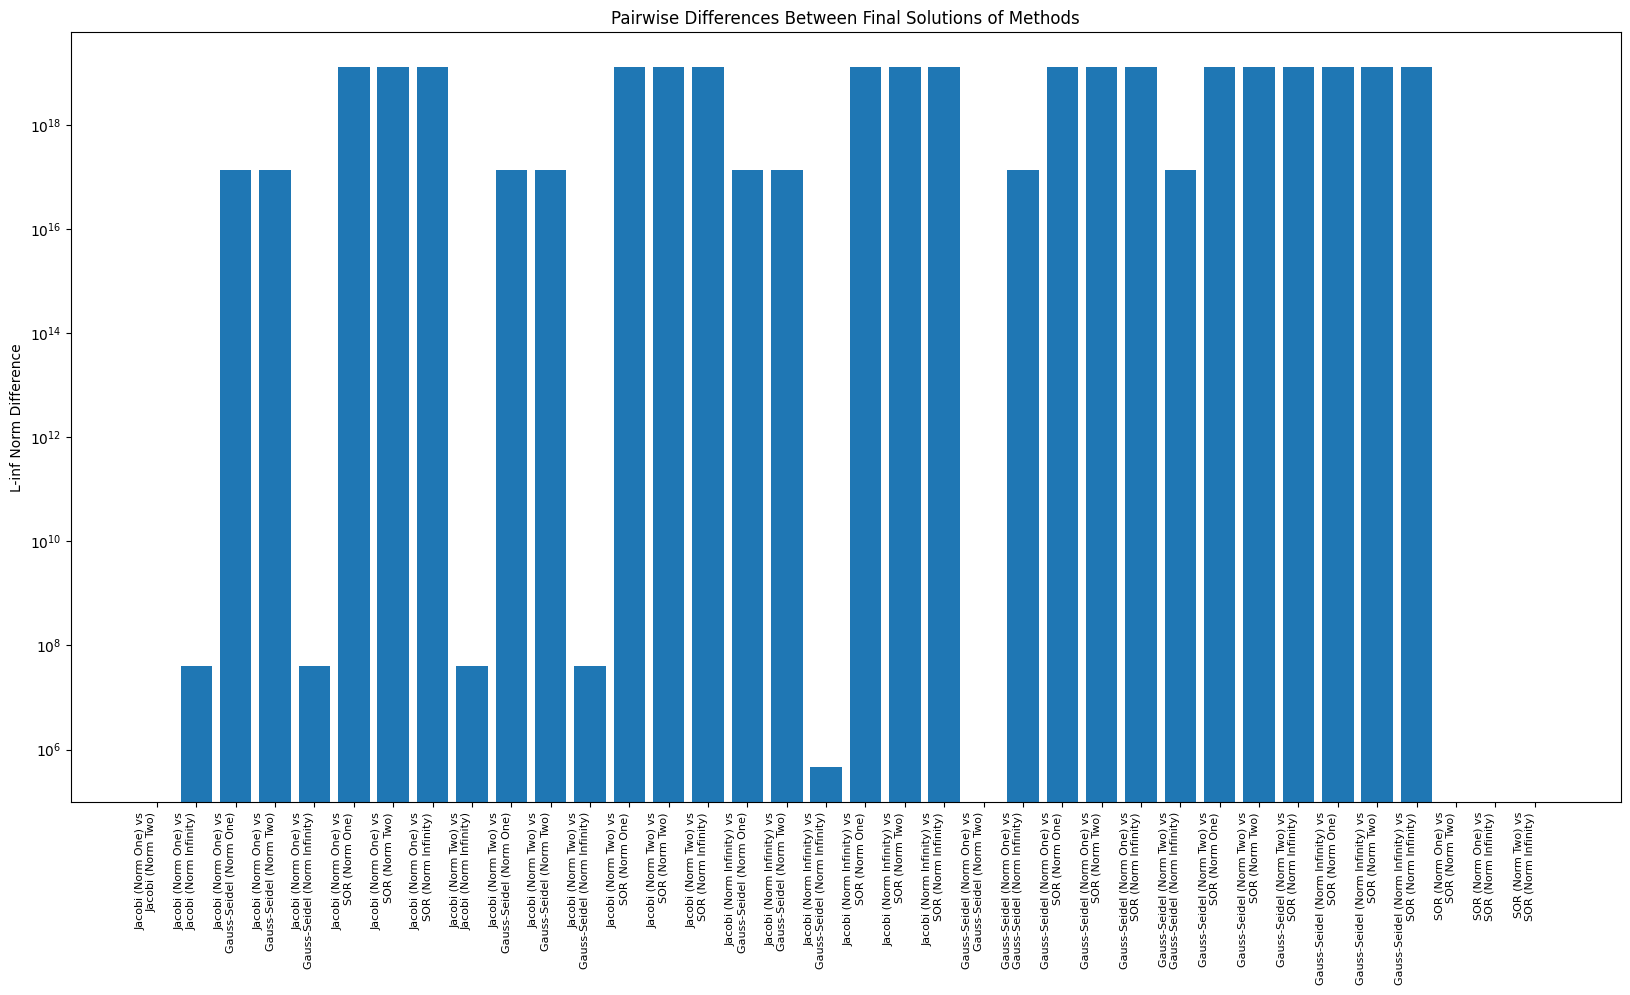

In [39]:
method_names = [name for name, _ in results]

n_methods = len(results)

diffs = []

labels = []

for i in range(n_methods):

    for j in range(i+1, n_methods):

        sol1 = results[i][1]
        sol2 = results[j][1]

        diff = np.max(np.abs(sol1 - sol2))

        diffs.append(diff)
        
        labels.append(f"{method_names[i]} vs\n{method_names[j]}")

# Plot
plt.figure(figsize=(20, 10))
bars = plt.bar(range(len(diffs)), diffs, tick_label=labels)
plt.yscale('log')
plt.ylabel("L-inf Norm Difference")
plt.title("Pairwise Differences Between Final Solutions of Methods")
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.show()